# ASE ice shelf melt rates

Closer inspection of melt rate and bottom temp/salt conditions in the Amundsen Sea
Based on notebook from Wilton Aguiar

In [1]:
import intake
import re
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean as cm
import glob
import matplotlib.colors as col
import cf_xarray as cf
# need to install opencv-python for this:
import cv2
import warnings
import logging
from scipy.ndimage import distance_transform_edt
import scipy.ndimage as nd
from scipy.interpolate import griddata
from matplotlib.animation import FuncAnimation
import imageio.v3 as iio
import glob
import imageio.v3 as iio
import cmocean.cm as cm
import pandas as pd
import matplotlib.gridspec as gridspec
import cmocean
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cmocean

logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)



In [2]:
from dask.distributed import Client

In [3]:
client = Client(threads_per_worker = 1)

2026-08-06 14:47:51,756 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:39015 (pid=2726779) exceeded 95% memory budget. Restarting...
2026-08-06 14:47:51,848 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:39015 (pid=2726779) is slow to accept SIGTERM; sending SIGKILL
2026-08-06 14:47:52,209 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:39015' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('getitem-c0a14657f641eff02ace6cd87299da98', 0, 0, 2, 9), ('getitem-c0a14657f641eff02ace6cd87299da98', 0, 0, 1, 6)} (stimulus_id='handle-worker-cleanup-1785991672.2087777')
2026-08-06 14:47:52,491 - distributed.nanny - WARNING - Restarting worker
2026-08-06 14:47:52,531 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:37273 (pid=2726693) exceeded 95% memory budget. Restarting...
2026-08-06 14:47:52,571 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:37273 (pid=2726693) is slow to a

In [4]:
#catalogs
catalog_new = intake.open_esm_datastore(
    "/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Intake_catalogs/pananice-shelf-new-config.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)
catalog_old = intake.open_esm_datastore(
    "/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Intake_catalogs/pananice-shelf-old-config.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)

catalog = intake.cat.access_nri

In [5]:
# Classic importer #####################################################

def importer_classic(experiment,catalog,variable, frequency = 'fx',start_time=0,end_time=0,chunks=''):
    xarray_open_kwargs = {"chunks": chunks,'decode_timedelta':True}
    if variable == 'volcello' and experiment == 'panant-01-zstar-ACCESSyr2':
        file_id='ocean.1mon.nv:2.xh:3600.xq:3601.yh:845.yq:846.z_i:76.z_l:75'
        var = catalog[experiment].search(variable=variable, frequency = frequency,file_id = file_id).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    elif experiment == 'panant-005-zstar-ACCESSyr2' and (variable == 'volcello' or variable == 'T_adx' or variable == 'T_ady' or variable=='thetao'):
        file_id='ocean.1mon.nv:2.xh:7200.xq:7201.yh:1690.yq:1691.z_i:76.z_l:75'
        var = catalog[experiment].search(variable=variable, frequency = frequency,file_id = file_id).to_dask(xarray_open_kwargs=xarray_open_kwargs)
    elif experiment == 'panant-0025-zstar-ACCESSyr2' and (variable == 'volcello' or variable == 'T_adx' or variable == 'T_ady' or variable=='thetao'):
        file_id='ocean.1mon.nv:2.xh:14400.xq:14401.yh:3383.yq:3384.z_i:76.z_l:75'
        var = catalog[experiment].search(variable=variable, frequency = frequency,file_id = file_id).to_dask(xarray_open_kwargs=xarray_open_kwargs)
    elif frequency == 'fx': 
        var = catalog[experiment].search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    else:
        var = catalog[experiment].search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs=xarray_open_kwargs)
    if start_time!=0:
        time_slice='slice(start_time,end_time)'
        return eval("var." + variable + ".sel(time=" + time_slice + ")")
    elif start_time ==0:
        return eval("var." + variable)

# defining list variables function
def intakelist(catalog,experiment):
    return catalog[experiment].unique().variable




# ghost experiment importer #####################################################
def importer(experiment,catalog,variable, frequency = 'fx',start_time=0,end_time=0,chunks=''):
    xarray_open_kwargs = {"chunks": chunks,'decode_timedelta':True}
    if variable == 'volcello':
        file_id='ocean.1mon.nv:2.xh:3600.xq:3601.yh:845.yq:846.z_i:76.z_l:75'
        var = catalog.search(variable=variable, frequency = frequency,file_id = file_id).to_dask(xarray_open_kwargs=xarray_open_kwargs)
    elif variable == 'thetao_z':
        file_id='ocean.1mon.nv:2.xh:3600.xq:3601.yh:845.yq:846.z_i:76.z_l:75'
        var = catalog.search(variable='thetao', frequency = frequency,file_id = file_id).to_dask(xarray_open_kwargs=xarray_open_kwargs)
        #renaming variable again
        variable='thetao'
    elif variable == 'so_z':
        file_id='ocean.1mon.nv:2.xh:3600.xq:3601.yh:845.yq:846.z_i:76.z_l:75'
        var = catalog.search(variable='so', frequency = frequency,file_id = file_id).to_dask(xarray_open_kwargs=xarray_open_kwargs)
        variable='so'; #renaming variable again
    elif variable == 'zos' and  experiment =='panant-01-zstar-ACCESSyr2':
        var = catalog[experiment].search(frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    elif experiment == 'panan-005-zstar-2001rerun' and (variable == 'volcello' or variable == 'T_adx' or variable == 'T_ady' or variable=='thetao'):
        file_id='ocean.1mon.nv:2.xh:7200.xq:7201.yh:1690.yq:1691.z_i:76.z_l:75'
        var = catalog.search(variable=variable, frequency = frequency,file_id = file_id).to_dask(xarray_open_kwargs=xarray_open_kwargs)
    elif experiment == 'panant-0025-zstar-ACCESSyr2' and (variable == 'volcello' or variable == 'T_adx' or variable == 'T_ady' or variable=='thetao'):
        file_id='ocean.1mon.nv:2.xh:14400.xq:14401.yh:3383.yq:3384.z_i:76.z_l:75'
        var = catalog.search(variable=variable, frequency = frequency,file_id = file_id).to_dask(xarray_open_kwargs=xarray_open_kwargs)
    elif frequency == 'fx': 
        var = catalog.search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    else:
        var = catalog.search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs=xarray_open_kwargs)
    if start_time!=0:
        time_slice='slice(start_time,end_time)'
        return eval("var." + variable + ".sel(time=" + time_slice + ")")
    elif start_time ==0:
        return eval("var." + variable)

# THis definition works only for unique catalogs
def intakelist(catalog):
    return catalog.unique().variable

In [26]:
lat_slice = slice(-80,-60)

In [49]:

# Import temp, salt and melt rate - just use a single year (1979) for now.

#Potential Temperature
bot_temp = xr.open_mfdataset('/scratch/oz91/akm157/access-om3/archive/access-rom3-panan4km-iceshelf/output*/access-om3.mom6.2d.tob.1mon.mean.1979.nc').tob.sel(yh=lat_slice,xh=lon_slice_Amundsen)

#Salinity
bot_salt = xr.open_mfdataset('/scratch/oz91/akm157/access-om3/archive/access-rom3-panan4km-iceshelf/output*/access-om3.mom6.2d.sob.1mon.mean.1979.nc').sob.sel(yh=lat_slice,xh=lon_slice_Amundsen)

#melt rate
mr = xr.open_mfdataset('/scratch/oz91/akm157/access-om3/archive/access-rom3-panan4km-iceshelf/output*/access-om3.mom6.2d.melt.1mon.mean.1979.nc').melt.sel(yT=lat_slice,xT=lon_slice_Amundsen)


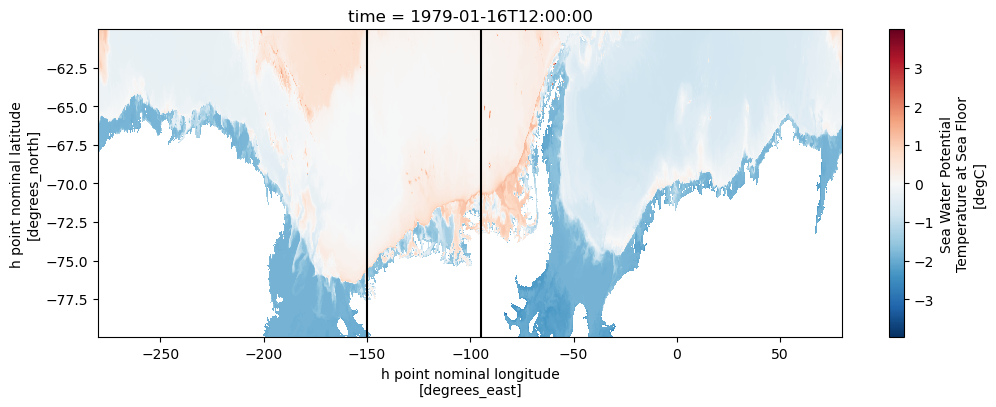

In [28]:
plt.figure(figsize=(12,4))
bot_temp.isel(time=0).plot()
plt.plot([-95,-95],[-55,-93],'k')
plt.plot([-150,-150],[-55,-93],'k')
lon_slice_Amundsen = slice(-150,-95) #setting the AMundsen slice
#Ill make a big zonal mean transect + additional transects every 11 degrees

# Make masks

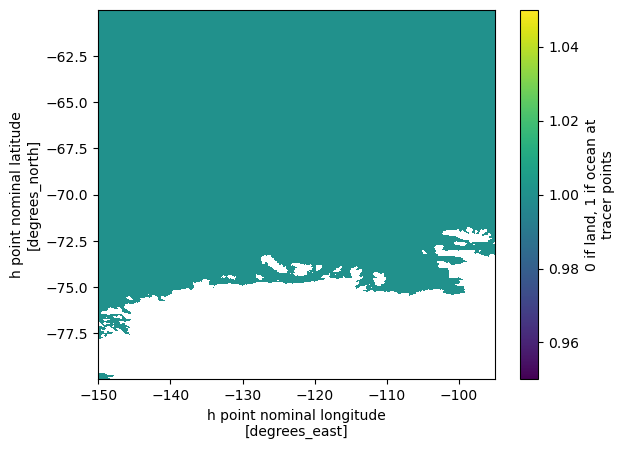

In [157]:
import xgcm
Static = xr.open_dataset('/g/data/ik11/outputs/access-rom3-panan/MC_4km_jra_iaf+regionalpanan+isf/output000/access-om3.mom6.static.nc')

grid = xgcm.Grid(Static, 
                 coords = {"x":{"center":"xh","outer":"xq"},
                             "y":{"center":"yh","outer":"yq"}},
                 periodic = "x",
                 autoparse_metadata = False)

e = xr.open_dataset('/scratch/oz91/akm157/access-om3/archive/access-rom3-panan4km-iceshelf/output038/access-om3.mom6.3d.e.z.1mon.mean.1978.nc')
layer_interfaces = e.e.isel(time = 0)
e_on_yq = grid.interp(layer_interfaces,"y")

mask_ocean = Static.wet.sel(yh=lat_slice,xh=lon_slice_Amundsen).compute()
mask_ocean_nan = mask_ocean.where(mask_ocean)
mask_ocean_nan.plot()

deptho = Static.deptho.sel(yh=lat_slice,xh=lon_slice_Amundsen).compute()

In [39]:
# mask_shelf = xr.open_dataset('/g/data/x77/cy8964/mom6/input/input-8km/150925/salt_restore_mask.nc').rename({'ny':'yh','nx':'xh'})
# mask_shelf['xh'] = bot_temp.xh.values
# mask_shelf['yh'] = bot_temp.yh.values
# mask_shelf.mask.plot()

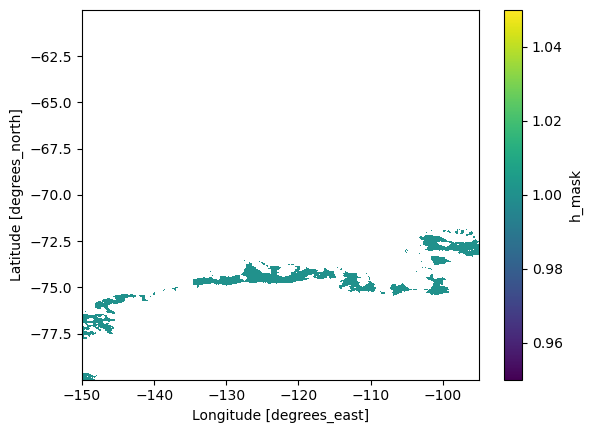

In [82]:
#making the ice shelf mask
IShelf_thick = xr.open_dataset('/g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo/claires_input/ice_shelf_thick_Bgrid_fixed.nc')
mask_iceshelf_full_nan = IShelf_thick.h_mask.rename({'ny':'yT','nx':'xT'}).where(IShelf_thick.h_mask.rename({'ny':'yT','nx':'xT'}))
mask_iceshelf = IShelf_thick.h_mask.rename({'ny':'yT','nx':'xT'}).sel(yT=lat_slice,xT=lon_slice_Amundsen).compute()
mask_iceshelf_nan = mask_iceshelf.where(mask_iceshelf)
mask_iceshelf_nan.plot()


In [78]:
(X,Y) = np.meshgrid(Static.xh.values, Static.yh.values)
X.shape

(1442, 4320)

In [92]:

(X,Y) = np.meshgrid(Static.xh.values, Static.yh.values)

def inpolygon(xq, yq, xv, yv):
    from matplotlib import path
    shape = xq.shape
    xq = xq.reshape(-1)
    yq = yq.reshape(-1)
    xv = xv.reshape(-1)
    yv = yv.reshape(-1)
    q = [(xq[i], yq[i]) for i in range(xq.shape[0])]
    p = path.Path([(xv[i], yv[i]) for i in range(xv.shape[0])])
    return p.contains_points(q).reshape(shape)
    
# make masks
poly_pig = np.array([
    [-99,-75.5],
    [-103,-75.5],
    [-103,-74.2],
    [-99,-74.2],
    [-98,-75]])
mask_roi_pig = inpolygon(X, Y,poly_pig[:,0], poly_pig[:,1])
mask_pig_nan = (mask_iceshelf_full_nan*mask_roi_pig).sel(yT=lat_slice,xT=lon_slice_Amundsen)
mask_pig_nan = mask_pig_nan.where(mask_pig_nan)

# make masks
poly_thw = np.array([
    [-108.5,-74.5],
    [-107.9,-75.5],
    [-103,-75.5],
    [-103,-75],
    [-108,-74]])
mask_roi_thw = inpolygon(X, Y,poly_thw[:,0], poly_thw[:,1])
mask_thw_nan = (mask_iceshelf_full_nan*mask_roi_thw).sel(yT=lat_slice,xT=lon_slice_Amundsen)
mask_thw_nan = mask_thw_nan.where(mask_thw_nan)




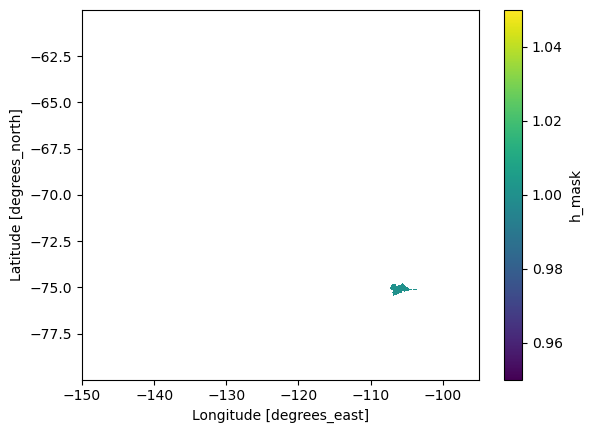

In [93]:
mask_thw_nan.plot()

# make plots of bottom temp and melt rate. annual mean and rough seasonal means.

In [62]:
temp_mean = bot_temp.mean("time") * mask_ocean_nan
salt_mean = bot_salt.mean("time") * mask_ocean_nan
melt_mean = mr.mean("time") * mask_iceshelf_nan



In [109]:
melt_mean_thw = (melt_mean*mask_thw_nan).mean(dim=('xT','yT')).values.round(1)
melt_mean_pig = (melt_mean*mask_pig_nan).mean(dim=('xT','yT')).values.round(1)


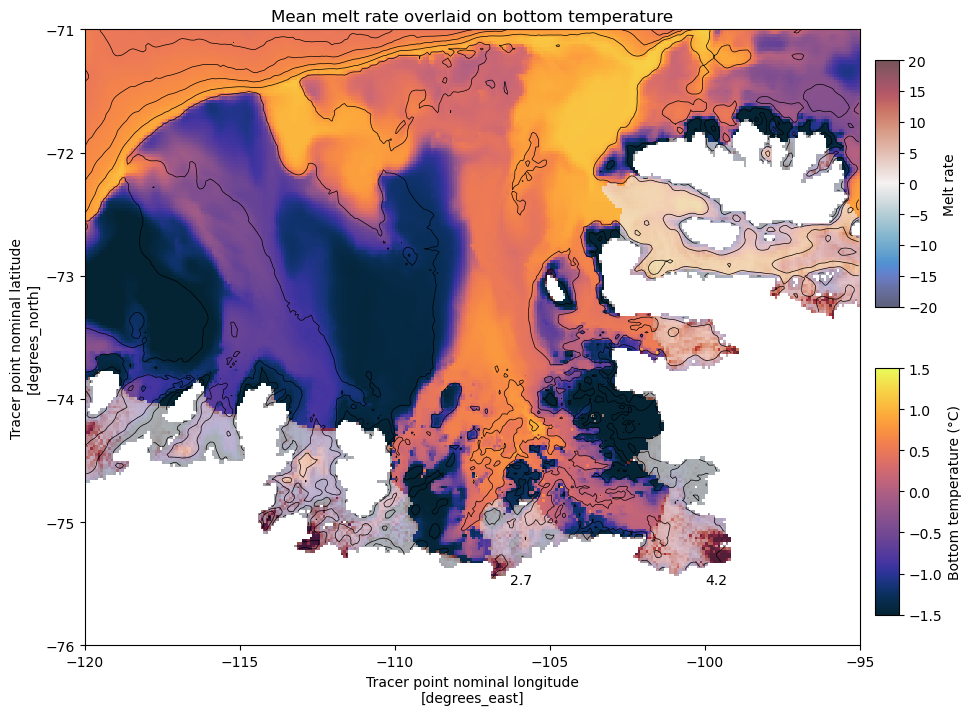

In [110]:


fig = plt.figure(figsize=(10,8))
gs = gridspec.GridSpec(1,1,hspace=0.03)
ax = fig.add_subplot(gs[0])

im2 = temp_mean.plot(ax=ax, cmap=cmocean.cm.thermal,
                     add_colorbar=False, vmin=-1.5, vmax=1.5)

cax2 = inset_axes(ax, width="3%", height="40%", loc="lower left",
                  bbox_to_anchor=(1.02,0.05,1,1),
                  bbox_transform=ax.transAxes, borderpad=0)
plt.colorbar(im2, cax=cax2, label="Bottom temperature (°C)")

deptho.plot.contour(ax=ax,levels=[0,100,250,500,1000,1500,2000,2500,3000],
                    colors='k', linewidths=0.5,add_colorbar=False)

im1 = melt_mean.plot(ax=ax, cmap=cmocean.cm.balance, vmin=-20,vmax=20,
                     add_colorbar=False, alpha=0.7)

ax.text(-100,-75.5,str(melt_mean_pig))
ax.text(-106.3,-75.5,str(melt_mean_thw))


ax.set_xlim((-120,-95))
ax.set_ylim((-76,-71))

cax1 = inset_axes(ax, width="3%", height="40%", loc="upper left",
                  bbox_to_anchor=(1.02,-0.05,1,1),
                  bbox_transform=ax.transAxes, borderpad=0)
plt.colorbar(im1, cax=cax1, label="Melt rate")

ax.set_title("Mean melt rate overlaid on bottom temperature")
plt.show()

It looks like there is warm water flowing beneath THW and PIG - at least 0.5C, but it's not transferring up to the ice to drive corresponding melt?
For example, look at PIG with what looks like 0 to 0.5C water reaching beneath the cavity; likewise look at Abbott Ice Shelf - it has 1.0C water beneath it but very low melt rate. Is the warm water kept deep by strong stratification?
To do:
vertical transect into the cavity. What is temperature in the cavity and how well is it reaching the ice base?

# Transect to the cavity

In [254]:
#Potential Temperature
temp = xr.open_mfdataset('/scratch/oz91/akm157/access-om3/archive/access-rom3-panan4km-iceshelf/output*/access-om3.mom6.3d.temp.z.1mon.mean.1978.nc').temp.sel(yh=lat_slice,xh=lon_slice_Amundsen)
salt = xr.open_mfdataset('/scratch/oz91/akm157/access-om3/archive/access-rom3-panan4km-iceshelf/output*/access-om3.mom6.3d.salt.z.1mon.mean.1978.nc').salt.sel(yh=lat_slice,xh=lon_slice_Amundsen)


In [258]:
def mom6_section(da, e, lon_pts, lat_pts, n_per_segment=100):
    """
    Extract a section from a MOM6 DataArray.

    Parameters
    ----------
    da : DataArray
        (time,z_l,yh,xh) or (z_l,yh,xh)
    e : DataArray
        Layer interface depths (time,z_i,yq,xh) or (z_i,yq,xh)
    lon_pts,
    lat_pts,
    n_per_segment, default = 100

    Returns
    -------
    section : interpolated tracer
    distance_edge
    eta_edge
    eta : interpolated layer interface depths
    lon_track, lat_track, dist
    """

    lon_track, lat_track = interpolate_track(lon_pts, lat_pts, n_per_segment)
    dist = cumulative_distance(lon_track, lat_track)

    pts = xr.Dataset(coords={
        "points": ("points", np.arange(len(lon_track))),
        "xh": ("points", lon_track),
        "yh": ("points", lat_track),
        "yq": ("points", lat_track)
    })

    section = da.interp(xh=pts.xh, yh=pts.yh, method="linear")

    eta = (e.interp(xh=pts.xh, yh=pts.yh, method="linear")
             .bfill("points").ffill("points")
             .bfill("z_i").ffill("z_i"))

    dist_edge = np.empty(len(dist)+1)
    dist_edge[1:-1] = 0.5*(dist[:-1] + dist[1:])
    dist_edge[0] = dist[0] - 0.5*(dist[1]-dist[0])
    dist_edge[-1] = dist[-1] + 0.5*(dist[-1]-dist[-2])
    
    eta_edge = np.empty((eta.e.shape[0], eta.e.shape[1]+1))
    eta_edge[:,1:-1] = 0.5*(eta.e.values[:,:-1] + eta.e.values[:,1:])
    eta_edge[:,0] = eta.e.values[:,0]
    eta_edge[:,-1] = eta.e.values[:,-1]

    return section, dist_edge, eta_edge, eta, lon_track, lat_track, dist


def interpolate_track(lon_pts, lat_pts, n_per_segment=100):
    lon_pts = np.asarray(lon_pts)
    lat_pts = np.asarray(lat_pts)

    lon_out, lat_out = [], []
    for i in range(len(lon_pts)-1):
        lon_out.append(np.linspace(lon_pts[i], lon_pts[i+1], n_per_segment))
        lat_out.append(np.linspace(lat_pts[i], lat_pts[i+1], n_per_segment))

    return np.concatenate(lon_out), np.concatenate(lat_out)


def cumulative_distance(lon, lat):
    R = 6371e3
    lon = np.radians(lon)
    lat = np.radians(lat)

    dlon = np.diff(lon)
    dlat = np.diff(lat)
    a = np.sin(dlat/2)**2 + np.cos(lat[:-1])*np.cos(lat[1:])*np.sin(dlon/2)**2
    c = 2*np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return np.concatenate([[0], np.cumsum(R*c)])

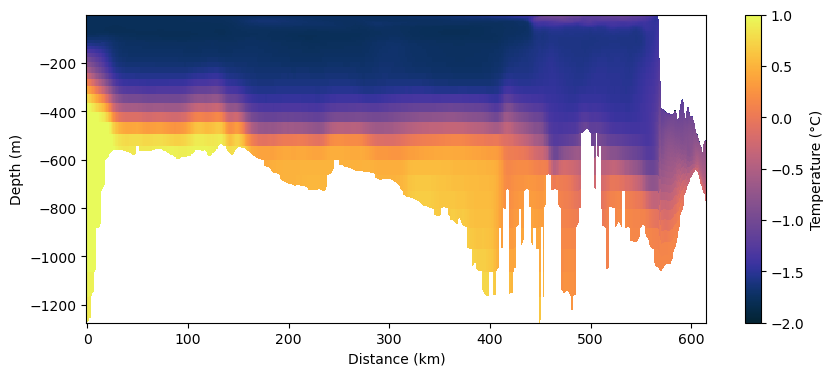

In [229]:
# example
xx=[-103,-106,-107,-106,-102,-100]
yy=[-71,-71.8,-72.5,-74,-75,-75.1]

temp_sec, dist_edge, eta_edge, eta, lon, lat, dist = mom6_section(temp.mean("time"), e.isel(time=0), xx, yy)
# temp_sec, X, eta_edge, dist_edge, lon, lat = mom6_section(temp.mean("time"), e.isel(time=0), xx, yy)

# salt_sec, eta, lon, lat, dist = mom6_section(salt.mean("time"), e.isel(time=0), xx, yy)


plt.figure(figsize=(10,4))
plt.pcolormesh(dist_edge/1000, eta_edge, temp_sec.values,
               shading="auto",
               cmap="cmo.thermal",
               vmin=-2, vmax=1)
# plt.gca().invert_yaxis()
plt.xlabel("Distance (km)")
plt.ylabel("Depth (m)")
plt.colorbar(label="Temperature (°C)")

In [243]:
# transect into the cavity


eta_edge.shape

(76, 501)

In [244]:
dist_edge.shape

(501,)

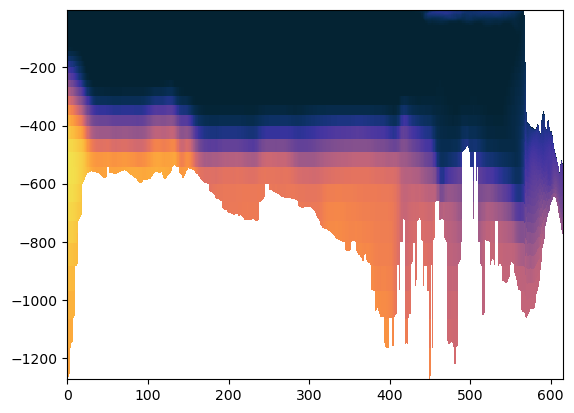

In [249]:
plt.pcolormesh(dist_edge/1000, eta_edge, temp_sec.values,
                   shading="auto", cmap=cmocean.cm.thermal,
                   vmin=-1.5, vmax=1.5)

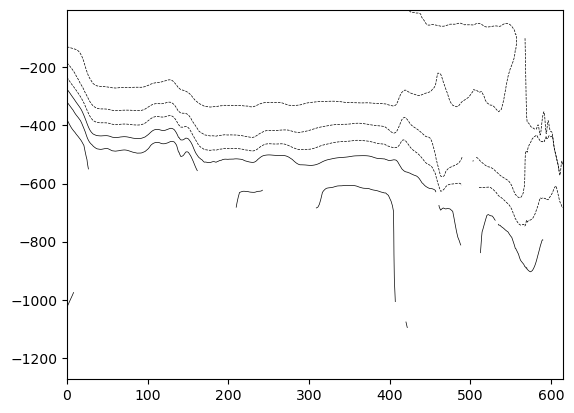

In [247]:
plt.contour(Xc, Yc, temp_sec.values,
                levels=[-1.5,-1,-0.5,0,0.5,1],
                colors='k', linewidths=0.5)

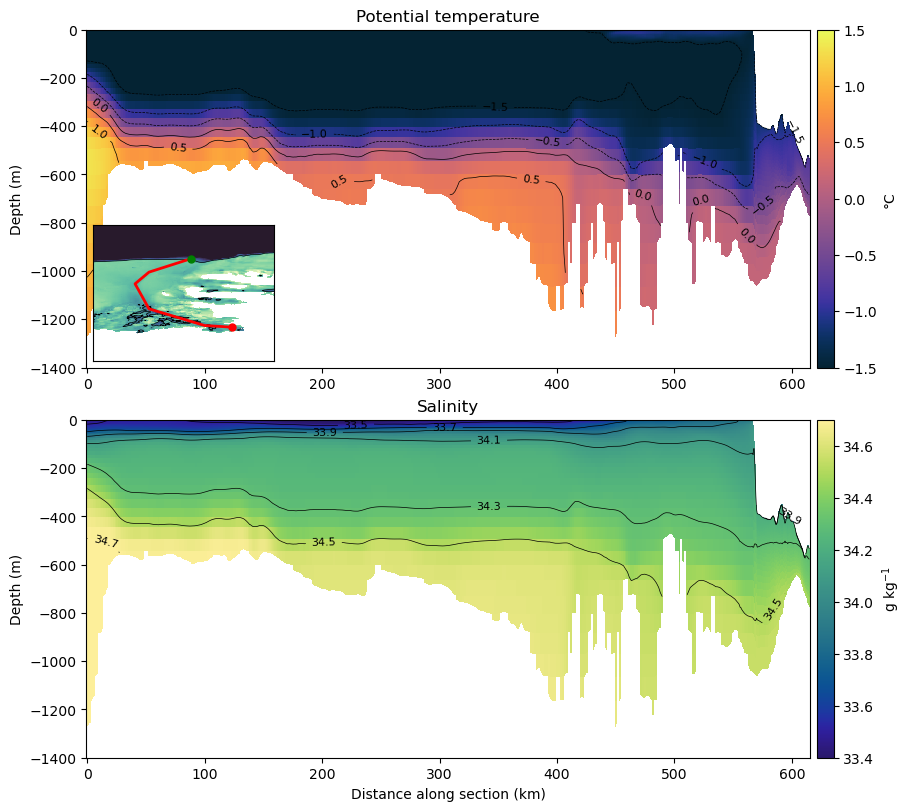

In [251]:

xx=[-103,-106,-107,-106,-102,-100]
yy=[-71,-71.8,-72.5,-74,-75,-75.1]

fig = plt.figure(figsize=(9,8), constrained_layout=True)
gs = gridspec.GridSpec(2,1,figure=fig)

temp_sec, dist_edge, eta_edge, eta, lon, lat, dist = mom6_section(temp.mean("time"), e.isel(time=0), xx, yy)
salt_sec, dist_edge, eta_edge, eta, lon, lat, dist = mom6_section(salt.mean("time"), e.isel(time=0), xx, yy)
# yes i know this is a hack, but i just want to get this working.
X, Y = np.meshgrid(dist_edge/1000, np.arange(eta_edge.shape[0]))
Y = eta_edge
Xc = 0.5*(X[:-1,:-1] + X[1:,1:])
Yc = 0.5*(Y[:-1,:-1] + Y[1:,1:])

# Temperature
ax = fig.add_subplot(gs[0])

im = ax.pcolormesh(dist_edge/1000, eta_edge, temp_sec.values,
                   shading="auto", cmap=cmocean.cm.thermal,
                   vmin=-1.5, vmax=1.5)

co = ax.contour(Xc, Yc, temp_sec.values,
                levels=[-1.5,-1,-0.5,0,0.5,1],
                colors='k', linewidths=0.5)

ax.clabel(co, fontsize=8)
# ax.invert_yaxis()
ax.set_ylim(-1400,0)
ax.set_ylabel("Depth (m)")
ax.set_title("Potential temperature")
plt.colorbar(im, ax=ax, pad=0.01, label="°C")

# Inset map
axins = inset_axes(ax, width="25%", height="40%", loc="lower left")

deptho.plot(ax=axins, cmap='cmo.deep', add_colorbar=False, vmin=0, vmax=2000)
axins.contour(deptho.xh, deptho.yh, deptho,
              levels=[1000], colors='k', linewidths=0.5)

axins.plot(xx, yy, '-r', lw=2)
axins.plot(xx[0], yy[0], 'go', ms=5)
axins.plot(xx[-1], yy[-1], 'ro', ms=5)

# for i, (x, y) in enumerate(zip(xx, yy)):
#     axins.text(x, y, str(i+1), fontsize=8, ha='center', va='bottom')

axins.set_xlim(min(xx)-3, max(xx)+3)
axins.set_ylim(min(yy)-2, max(yy)+2)
axins.set_xlabel("")
axins.set_ylabel("")
axins.set_xticks([])
axins.set_yticks([])
# axins.set_title("Transect", fontsize=9)


# Salinity
ax = fig.add_subplot(gs[1])

im = ax.pcolormesh(dist_edge/1000, eta_edge, salt_sec.values,
                   shading="auto", cmap=cmocean.cm.haline,
                   vmin=33.4, vmax=34.7)

co = ax.contour(Xc, Yc, salt_sec.values,
                levels=np.arange(33.5,34.8,0.2),
                colors='k', linewidths=0.5)

ax.clabel(co, fontsize=8)
# ax.invert_yaxis()
ax.set_ylim(-1400,0)
ax.set_xlabel("Distance along section (km)")
ax.set_ylabel("Depth (m)")
ax.set_title("Salinity")
plt.colorbar(im, ax=ax, pad=0.01, label="g kg$^{-1}$")

plt.show()

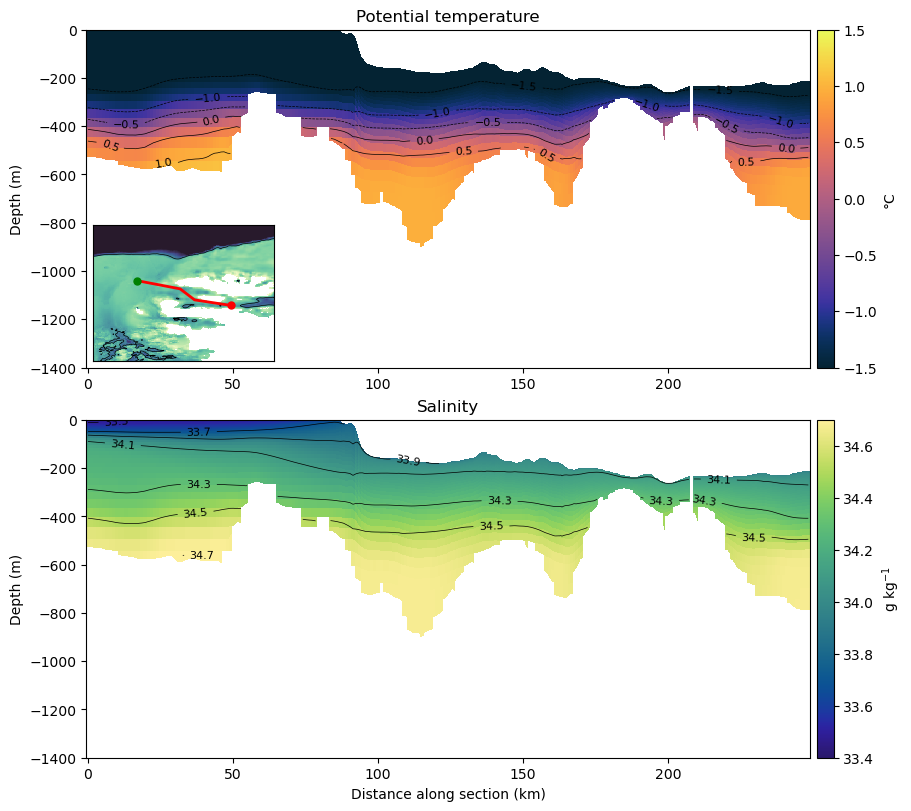

In [252]:

xx=[-105,-102,-101,-98.5]
yy=[-72,-72.3,-72.7,-72.9]
fig = plt.figure(figsize=(9,8), constrained_layout=True)
gs = gridspec.GridSpec(2,1,figure=fig)

temp_sec, dist_edge, eta_edge, eta, lon, lat, dist = mom6_section(temp.mean("time"), e.isel(time=0), xx, yy)
salt_sec, dist_edge, eta_edge, eta, lon, lat, dist = mom6_section(salt.mean("time"), e.isel(time=0), xx, yy)
# yes i know this is a hack, but i just want to get this working.
X, Y = np.meshgrid(dist_edge/1000, np.arange(eta_edge.shape[0]))
Y = eta_edge
Xc = 0.5*(X[:-1,:-1] + X[1:,1:])
Yc = 0.5*(Y[:-1,:-1] + Y[1:,1:])

# Temperature
ax = fig.add_subplot(gs[0])

im = ax.pcolormesh(dist_edge/1000, eta_edge, temp_sec.values,
                   shading="auto", cmap=cmocean.cm.thermal,
                   vmin=-1.5, vmax=1.5)

co = ax.contour(Xc, Yc, temp_sec.values,
                levels=[-1.5,-1,-0.5,0,0.5,1],
                colors='k', linewidths=0.5)

ax.clabel(co, fontsize=8)
# ax.invert_yaxis()
ax.set_ylim(-1400,0)
ax.set_ylabel("Depth (m)")
ax.set_title("Potential temperature")
plt.colorbar(im, ax=ax, pad=0.01, label="°C")

# Inset map
axins = inset_axes(ax, width="25%", height="40%", loc="lower left")

deptho.plot(ax=axins, cmap='cmo.deep', add_colorbar=False, vmin=0, vmax=2000)
axins.contour(deptho.xh, deptho.yh, deptho,
              levels=[1000], colors='k', linewidths=0.5)

axins.plot(xx, yy, '-r', lw=2)
axins.plot(xx[0], yy[0], 'go', ms=5)
axins.plot(xx[-1], yy[-1], 'ro', ms=5)

# for i, (x, y) in enumerate(zip(xx, yy)):
#     axins.text(x, y, str(i+1), fontsize=8, ha='center', va='bottom')

axins.set_xlim(min(xx)-3, max(xx)+3)
axins.set_ylim(min(yy)-2, max(yy)+2)
axins.set_xlabel("")
axins.set_ylabel("")
axins.set_xticks([])
axins.set_yticks([])
# axins.set_title("Transect", fontsize=9)


# Salinity
ax = fig.add_subplot(gs[1])

im = ax.pcolormesh(dist_edge/1000, eta_edge, salt_sec.values,
                   shading="auto", cmap=cmocean.cm.haline,
                   vmin=33.4, vmax=34.7)

co = ax.contour(Xc, Yc, salt_sec.values,
                levels=np.arange(33.5,34.8,0.2),
                colors='k', linewidths=0.5)

ax.clabel(co, fontsize=8)
# ax.invert_yaxis()
ax.set_ylim(-1400,0)
ax.set_xlabel("Distance along section (km)")
ax.set_ylabel("Depth (m)")
ax.set_title("Salinity")
plt.colorbar(im, ax=ax, pad=0.01, label="g kg$^{-1}$")

plt.show()

# now make seasonal plots

In [261]:
#define season indices
seasons = {"DJF":[12,1,2], "MAM":[3,4,5], "JJA":[6,7,8], "SON":[9,10,11]}

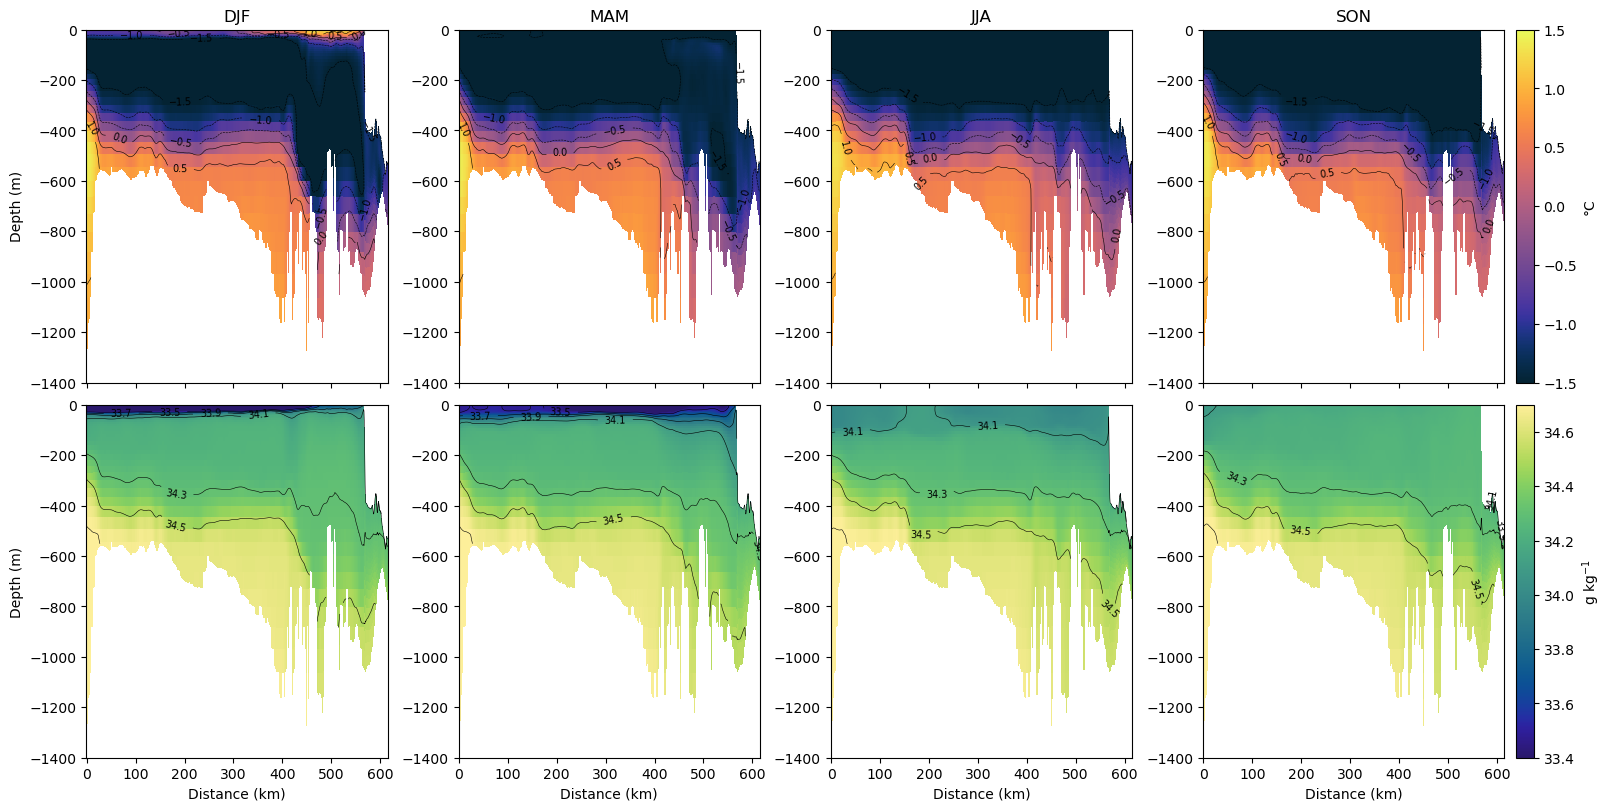

In [262]:
# PIG section

xx=[-103,-106,-107,-106,-102,-100]
yy=[-71,-71.8,-72.5,-74,-75,-75.1]



fig = plt.figure(figsize=(16,8), constrained_layout=True)
gs = gridspec.GridSpec(2,4,figure=fig)

# first make X,Y points, which won't change
_, dist_edge, eta_edge, eta, lon, lat, dist = mom6_section(temp.isel(time=0), e.isel(time=0), xx, yy)

X, Y = np.meshgrid(dist_edge/1000, np.arange(eta_edge.shape[0]))
Y = eta_edge
Xc = 0.5*(X[:-1,:-1] + X[1:,1:])
Yc = 0.5*(Y[:-1,:-1] + Y[1:,1:])


for i, (season, months) in enumerate(seasons.items()):

    temp_seas = temp.where(temp.time.dt.month.isin(months), drop=True).mean("time") # group by month and mean
    salt_seas = salt.where(salt.time.dt.month.isin(months), drop=True).mean("time")

    temp_sec, _, _, _, _, _, _ = mom6_section(temp_seas, e.isel(time=0), xx, yy) # extract relevant seasonal transect.
    salt_sec, _, _, _, _, _, _ = mom6_section(salt_seas, e.isel(time=0), xx, yy)

    # temperature
    ax = fig.add_subplot(gs[0,i])
    im = ax.pcolormesh(dist_edge/1000, eta_edge, temp_sec.values, shading="auto", cmap=cmocean.cm.thermal, vmin=-1.5, vmax=1.5)
    co = ax.contour(Xc, Yc, temp_sec.values, levels=[-1.5,-1,-0.5,0,0.5,1], colors='k', linewidths=0.4)
    ax.clabel(co, fontsize=7)
    ax.set_ylim(-1400,0)
    ax.set_title(season)
    ax.set_ylabel("Depth (m)" if i==0 else "")
    ax.set_xticklabels([])
    if i==3: plt.colorbar(im, ax=ax, pad=0.02, label="°C")

    # salinity
    ax = fig.add_subplot(gs[1,i])
    im = ax.pcolormesh(dist_edge/1000, eta_edge, salt_sec.values, shading="auto", cmap=cmocean.cm.haline, vmin=33.4, vmax=34.7)
    co = ax.contour(Xc, Yc, salt_sec.values, levels=np.arange(33.5,34.8,0.2), colors='k', linewidths=0.4)
    ax.clabel(co, fontsize=7)
    ax.set_ylim(-1400,0)
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Depth (m)" if i==0 else "")
    if i==3: plt.colorbar(im, ax=ax, pad=0.02, label="g kg$^{-1}$")

plt.show()


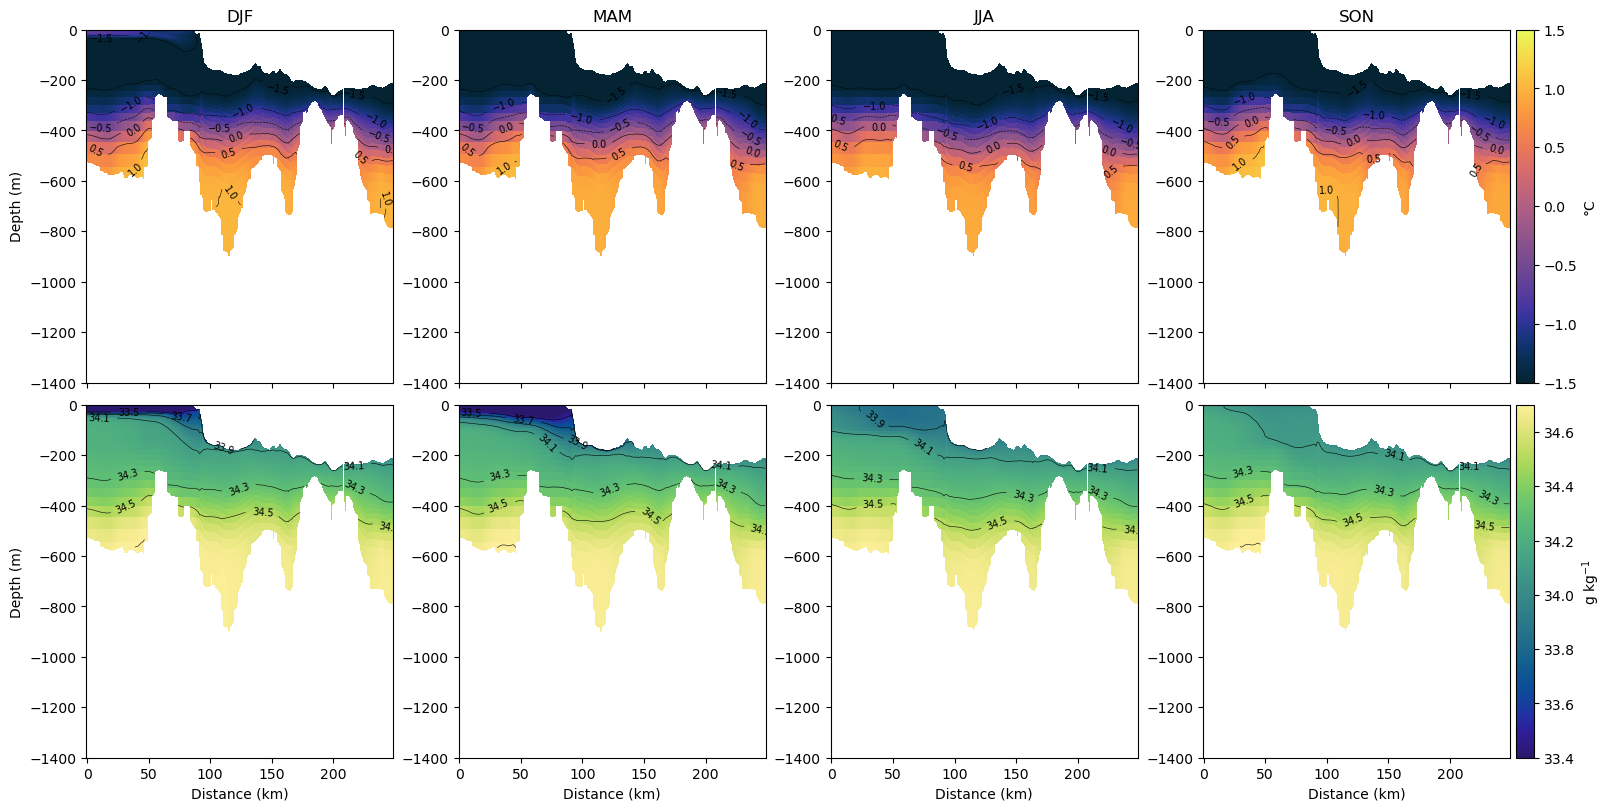

In [260]:
# Abbott IS section
xx=[-105,-102,-101,-98.5]
yy=[-72,-72.3,-72.7,-72.9]

fig = plt.figure(figsize=(16,8), constrained_layout=True)
gs = gridspec.GridSpec(2,4,figure=fig)

# first make X,Y points, which won't change
_, dist_edge, eta_edge, eta, lon, lat, dist = mom6_section(temp.isel(time=0), e.isel(time=0), xx, yy)

X, Y = np.meshgrid(dist_edge/1000, np.arange(eta_edge.shape[0]))
Y = eta_edge
Xc = 0.5*(X[:-1,:-1] + X[1:,1:])
Yc = 0.5*(Y[:-1,:-1] + Y[1:,1:])


for i, (season, months) in enumerate(seasons.items()):

    temp_seas = temp.where(temp.time.dt.month.isin(months), drop=True).mean("time") # group by month and mean
    salt_seas = salt.where(salt.time.dt.month.isin(months), drop=True).mean("time")

    temp_sec, _, _, _, _, _, _ = mom6_section(temp_seas, e.isel(time=0), xx, yy) # extract relevant seasonal transect.
    salt_sec, _, _, _, _, _, _ = mom6_section(salt_seas, e.isel(time=0), xx, yy)

    # temperature
    ax = fig.add_subplot(gs[0,i])
    im = ax.pcolormesh(dist_edge/1000, eta_edge, temp_sec.values, shading="auto", cmap=cmocean.cm.thermal, vmin=-1.5, vmax=1.5)
    co = ax.contour(Xc, Yc, temp_sec.values, levels=[-1.5,-1,-0.5,0,0.5,1], colors='k', linewidths=0.4)
    ax.clabel(co, fontsize=7)
    ax.set_ylim(-1400,0)
    ax.set_title(season)
    ax.set_ylabel("Depth (m)" if i==0 else "")
    ax.set_xticklabels([])
    if i==3: plt.colorbar(im, ax=ax, pad=0.02, label="°C")

    # salinity
    ax = fig.add_subplot(gs[1,i])
    im = ax.pcolormesh(dist_edge/1000, eta_edge, salt_sec.values, shading="auto", cmap=cmocean.cm.haline, vmin=33.4, vmax=34.7)
    co = ax.contour(Xc, Yc, salt_sec.values, levels=np.arange(33.5,34.8,0.2), colors='k', linewidths=0.4)
    ax.clabel(co, fontsize=7)
    ax.set_ylim(-1400,0)
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Depth (m)" if i==0 else "")
    if i==3: plt.colorbar(im, ax=ax, pad=0.02, label="g kg$^{-1}$")

plt.show()